In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import re
import numpy as np

C:\Users\mirna\anaconda3\envs\network_env\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [5]:
df = pd.read_csv('regular_modeling/bootstrap_results_all.csv')
df

,Cohort,Cohort Size,Num Features,Model,Metric,Mean,CI_Lower,CI_Upper,Formatted
0,Nationwide Cohort,339308,2077,LightGBM,ROC_AUC,0.823496,0.818931,0.827269,0.8235 (0.8189 - 0.8273)
1,Nationwide Cohort,339308,2077,LightGBM,PR_AUC,0.422927,0.413310,0.431426,0.4229 (0.4133 - 0.4314)
2,Nationwide Cohort,339308,2077,LightGBM,F1_Score,0.447369,0.438874,0.455026,0.4474 (0.4389 - 0.4550)
3,Nationwide Cohort,339308,2077,LightGBM,Accuracy,0.807354,0.803791,0.810397,0.8074 (0.8038 - 0.8104)
4,Nationwide Cohort,339308,2077,LightGBM,Precision,0.355398,0.347656,0.362328,0.3554 (0.3477 - 0.3623)
...,...,...,...,...,...,...,...,...,...
91,Texas Cohort,222953,4108,Logistic Regression,Accuracy,0.803336,0.799217,0.807204,0.8033 (0.7992 - 0.8072)
92,Texas Cohort,222953,4108,Logistic Regression,Precision,0.402702,0.393403,0.413030,0.4027 (0.3934 - 0.4130)
93,Texas Cohort,222953,4108,Logistic Regression,Recall_Sensitivity,0.583979,0.573065,0.596468,0.5840 (0.5731 - 0.5965)
94,Texas Cohort,222953,4108,Logistic Regression,Specificity,0.843077,0.838820,0.846556,0.8431 (0.8388 - 0.8466)


In [6]:
df['Model'].unique()

<ArrowStringArray>
[           'LightGBM',             'XGBoost',            'CatBoost',
       'Random Forest',   'Gradient Boosting', 'Logistic Regression']
Length: 6, dtype: str

In [7]:
id_cols = [
    "Cohort",
    "Cohort Size",
    "Num Features",
    "Model",
]

# Ensure no accidental duplicate result rows per model/metric.
# If duplicates are expected, choose an appropriate aggregation function.
results_wide_df = (
    df
    .pivot_table(
        index=id_cols,
        columns="Metric",
        values=['Formatted'],
        aggfunc="first"
    )
)

results_wide_df.columns = [
    f"{metric.replace('-', '_').replace(' ', '_')}_{stat}"
    for stat, metric in results_wide_df.columns
]

results_wide_df = results_wide_df.reset_index()
results_wide_df

,Cohort,Cohort Size,Num Features,Model,Accuracy_Formatted,Brier_Score_Formatted,F1_Score_Formatted,PR_AUC_Formatted,Precision_Formatted,ROC_AUC_Formatted,Recall_Sensitivity_Formatted,Specificity_Formatted
0,Nationwide Cohort,339308,2077,CatBoost,0.8150 (0.8117 - 0.8181),0.1764 (0.1749 - 0.1778),0.4492 (0.4415 - 0.4572),0.4218 (0.4124 - 0.4309),0.3650 (0.3567 - 0.3726),0.8227 (0.8184 - 0.8270),0.5839 (0.5747 - 0.5935),0.8493 (0.8464 - 0.8521)
1,Nationwide Cohort,339308,2077,Gradient Boosting,0.7965 (0.7937 - 0.7995),0.1845 (0.1833 - 0.1857),0.4297 (0.4225 - 0.4365),0.3900 (0.3810 - 0.3994),0.3368 (0.3302 - 0.3428),0.8062 (0.8013 - 0.8106),0.5935 (0.5840 - 0.6036),0.8266 (0.8237 - 0.8299)
2,Nationwide Cohort,339308,2077,LightGBM,0.8074 (0.8038 - 0.8104),0.1648 (0.1634 - 0.1662),0.4474 (0.4389 - 0.4550),0.4229 (0.4133 - 0.4314),0.3554 (0.3477 - 0.3623),0.8235 (0.8189 - 0.8273),0.6036 (0.5930 - 0.6139),0.8376 (0.8344 - 0.8404)
3,Nationwide Cohort,339308,2077,Logistic Regression,0.8127 (0.8101 - 0.8153),0.1839 (0.1824 - 0.1852),0.4238 (0.4169 - 0.4321),0.3825 (0.3731 - 0.3922),0.3517 (0.3443 - 0.3596),0.7959 (0.7911 - 0.8002),0.5332 (0.5234 - 0.5448),0.8542 (0.8514 - 0.8570)
4,Nationwide Cohort,339308,2077,Random Forest,0.7720 (0.7686 - 0.7750),0.1474 (0.1466 - 0.1483),0.3918 (0.3845 - 0.3984),0.3290 (0.3195 - 0.3378),0.2989 (0.2926 - 0.3047),0.7739 (0.7690 - 0.7785),0.5684 (0.5583 - 0.5779),0.8022 (0.7987 - 0.8054)
5,Nationwide Cohort,339308,2077,XGBoost,0.8097 (0.8063 - 0.8127),0.1688 (0.1674 - 0.1702),0.4486 (0.4409 - 0.4559),0.4244 (0.4141 - 0.4331),0.3584 (0.3509 - 0.3649),0.8228 (0.8186 - 0.8270),0.5993 (0.5893 - 0.6096),0.8409 (0.8375 - 0.8442)
6,Texas Cohort,222953,4108,CatBoost,0.7976 (0.7934 - 0.8015),0.1737 (0.1720 - 0.1760),0.4858 (0.4766 - 0.4938),0.4821 (0.4696 - 0.4936),0.3979 (0.3891 - 0.4070),0.8276 (0.8228 - 0.8321),0.6235 (0.6107 - 0.6353),0.8291 (0.8249 - 0.8331)
7,Texas Cohort,222953,4108,Gradient Boosting,0.7571 (0.7532 - 0.7624),0.1906 (0.1893 - 0.1918),0.4436 (0.4350 - 0.4503),0.4080 (0.3966 - 0.4190),0.3420 (0.3339 - 0.3494),0.7957 (0.7908 - 0.8005),0.6311 (0.6197 - 0.6426),0.7800 (0.7759 - 0.7846)
8,Texas Cohort,222953,4108,LightGBM,0.7990 (0.7948 - 0.8035),0.1633 (0.1615 - 0.1654),0.4848 (0.4762 - 0.4924),0.4829 (0.4715 - 0.4945),0.3995 (0.3913 - 0.4074),0.8272 (0.8226 - 0.8320),0.6166 (0.6044 - 0.6279),0.8321 (0.8281 - 0.8360)
9,Texas Cohort,222953,4108,Logistic Regression,0.8033 (0.7992 - 0.8072),0.1759 (0.1740 - 0.1780),0.4767 (0.4671 - 0.4861),0.4536 (0.4415 - 0.4648),0.4027 (0.3934 - 0.4130),0.8110 (0.8060 - 0.8157),0.5840 (0.5731 - 0.5965),0.8431 (0.8388 - 0.8466)


In [8]:
df_neural = pd.read_csv('regular_modeling/neural_bootstrap_results_all.csv')
df_neural

,Cohort,Cohort Size,Num Features,Model,Metric,Mean,CI_Lower,CI_Upper,Formatted
0,Nationwide Cohort,339308,2077,Standard MLP,ROC_AUC,0.789049,0.783904,0.793892,0.7890 (0.7839 - 0.7939)
1,Nationwide Cohort,339308,2077,Standard MLP,PR_AUC,0.377823,0.368330,0.387764,0.3778 (0.3683 - 0.3878)
2,Nationwide Cohort,339308,2077,Standard MLP,F1_Score,0.385332,0.379041,0.390753,0.3853 (0.3790 - 0.3908)
3,Nationwide Cohort,339308,2077,Standard MLP,Accuracy,0.690176,0.687052,0.693735,0.6902 (0.6871 - 0.6937)
4,Nationwide Cohort,339308,2077,Standard MLP,Precision,0.259068,0.253416,0.263527,0.2591 (0.2534 - 0.2635)
...,...,...,...,...,...,...,...,...,...
59,Texas Cohort,62449,758,HIR-M3 Transformer,Accuracy,0.631251,0.623359,0.638675,0.6313 (0.6234 - 0.6387)
60,Texas Cohort,62449,758,HIR-M3 Transformer,Precision,0.259431,0.247757,0.269993,0.2594 (0.2478 - 0.2700)
61,Texas Cohort,62449,758,HIR-M3 Transformer,Recall_Sensitivity,0.811817,0.794520,0.829353,0.8118 (0.7945 - 0.8294)
62,Texas Cohort,62449,758,HIR-M3 Transformer,Specificity,0.600092,0.591309,0.609474,0.6001 (0.5913 - 0.6095)


In [9]:
df_neural.columns

Index(['Cohort', 'Cohort Size', 'Num Features', 'Model', 'Metric', 'Mean',
       'CI_Lower', 'CI_Upper', 'Formatted'],
      dtype='str')

In [10]:
id_cols = [
    "Cohort",
    "Cohort Size",
    "Num Features",
    "Model",
]

results_wide = (
    df_neural
    .pivot_table(
        index=id_cols,
        columns="Metric",
        values=['Formatted'],
        aggfunc="first"
    )
)

results_wide.columns = [
    f"{metric.replace('-', '_').replace(' ', '_')}_{stat}"
    for stat, metric in results_wide.columns
]

results_wide = results_wide.reset_index()
results_wide

,Cohort,Cohort Size,Num Features,Model,Accuracy_Formatted,Brier_Score_Formatted,F1_Score_Formatted,PR_AUC_Formatted,Precision_Formatted,ROC_AUC_Formatted,Recall_Sensitivity_Formatted,Specificity_Formatted
0,Nationwide Cohort,339308,2077,HIR-M3 Transformer,0.5947 (0.5910 - 0.5984),0.2473 (0.2469 - 0.2478),0.2315 (0.2265 - 0.2377),0.1571 (0.1526 - 0.1615),0.1533 (0.1495 - 0.1576),0.5649 (0.5587 - 0.5714),0.4724 (0.4611 - 0.4824),0.6129 (0.6090 - 0.6167)
1,Nationwide Cohort,339308,2077,SAINT Transformer,0.4689 (0.4652 - 0.4723),0.2481 (0.2478 - 0.2485),0.2334 (0.2290 - 0.2374),0.1554 (0.1509 - 0.1595),0.1435 (0.1404 - 0.1462),0.5578 (0.5519 - 0.5641),0.6258 (0.6163 - 0.6349),0.4457 (0.4419 - 0.4492)
2,Nationwide Cohort,339308,2077,Standard MLP,0.6902 (0.6871 - 0.6937),0.1838 (0.1823 - 0.1855),0.3853 (0.3790 - 0.3908),0.3778 (0.3683 - 0.3878),0.2591 (0.2534 - 0.2635),0.7890 (0.7839 - 0.7939),0.7517 (0.7430 - 0.7607),0.6810 (0.6775 - 0.6844)
3,Nationwide Cohort,339308,2077,Standard Transformer,0.5764 (0.5719 - 0.5800),0.2483 (0.2480 - 0.2487),0.2327 (0.2275 - 0.2381),0.1567 (0.1525 - 0.1615),0.1519 (0.1482 - 0.1554),0.5641 (0.5581 - 0.5699),0.4973 (0.4874 - 0.5075),0.5881 (0.5839 - 0.5922)
4,Texas Cohort,62449,758,HIR-M3 Transformer,0.6313 (0.6234 - 0.6387),0.2107 (0.2075 - 0.2139),0.3932 (0.3794 - 0.4058),0.4030 (0.3762 - 0.4270),0.2594 (0.2478 - 0.2700),0.7803 (0.7701 - 0.7908),0.8118 (0.7945 - 0.8294),0.6001 (0.5913 - 0.6095)
5,Texas Cohort,62449,758,SAINT Transformer,0.5786 (0.5698 - 0.5875),0.2603 (0.2563 - 0.2640),0.3729 (0.3598 - 0.3859),0.3839 (0.3548 - 0.4081),0.2388 (0.2293 - 0.2492),0.7768 (0.7661 - 0.7863),0.8514 (0.8357 - 0.8683),0.5316 (0.5232 - 0.5417)
6,Texas Cohort,62449,758,Standard MLP,0.7345 (0.7274 - 0.7424),0.1699 (0.1664 - 0.1732),0.4341 (0.4177 - 0.4495),0.4238 (0.4012 - 0.4473),0.3163 (0.3027 - 0.3311),0.7932 (0.7823 - 0.8043),0.6919 (0.6708 - 0.7124),0.7419 (0.7341 - 0.7497)
7,Texas Cohort,62449,758,Standard Transformer,0.6475 (0.6389 - 0.6553),0.2077 (0.2047 - 0.2105),0.3984 (0.3843 - 0.4104),0.3939 (0.3668 - 0.4171),0.2660 (0.2546 - 0.2766),0.7782 (0.7683 - 0.7882),0.7930 (0.7748 - 0.8100),0.6224 (0.6144 - 0.6324)


In [11]:
results_modeling = pd.concat([results_wide_df, results_wide])
results_modeling

,Cohort,Cohort Size,Num Features,Model,Accuracy_Formatted,Brier_Score_Formatted,F1_Score_Formatted,PR_AUC_Formatted,Precision_Formatted,ROC_AUC_Formatted,Recall_Sensitivity_Formatted,Specificity_Formatted
0,Nationwide Cohort,339308,2077,CatBoost,0.8150 (0.8117 - 0.8181),0.1764 (0.1749 - 0.1778),0.4492 (0.4415 - 0.4572),0.4218 (0.4124 - 0.4309),0.3650 (0.3567 - 0.3726),0.8227 (0.8184 - 0.8270),0.5839 (0.5747 - 0.5935),0.8493 (0.8464 - 0.8521)
1,Nationwide Cohort,339308,2077,Gradient Boosting,0.7965 (0.7937 - 0.7995),0.1845 (0.1833 - 0.1857),0.4297 (0.4225 - 0.4365),0.3900 (0.3810 - 0.3994),0.3368 (0.3302 - 0.3428),0.8062 (0.8013 - 0.8106),0.5935 (0.5840 - 0.6036),0.8266 (0.8237 - 0.8299)
2,Nationwide Cohort,339308,2077,LightGBM,0.8074 (0.8038 - 0.8104),0.1648 (0.1634 - 0.1662),0.4474 (0.4389 - 0.4550),0.4229 (0.4133 - 0.4314),0.3554 (0.3477 - 0.3623),0.8235 (0.8189 - 0.8273),0.6036 (0.5930 - 0.6139),0.8376 (0.8344 - 0.8404)
3,Nationwide Cohort,339308,2077,Logistic Regression,0.8127 (0.8101 - 0.8153),0.1839 (0.1824 - 0.1852),0.4238 (0.4169 - 0.4321),0.3825 (0.3731 - 0.3922),0.3517 (0.3443 - 0.3596),0.7959 (0.7911 - 0.8002),0.5332 (0.5234 - 0.5448),0.8542 (0.8514 - 0.8570)
4,Nationwide Cohort,339308,2077,Random Forest,0.7720 (0.7686 - 0.7750),0.1474 (0.1466 - 0.1483),0.3918 (0.3845 - 0.3984),0.3290 (0.3195 - 0.3378),0.2989 (0.2926 - 0.3047),0.7739 (0.7690 - 0.7785),0.5684 (0.5583 - 0.5779),0.8022 (0.7987 - 0.8054)
5,Nationwide Cohort,339308,2077,XGBoost,0.8097 (0.8063 - 0.8127),0.1688 (0.1674 - 0.1702),0.4486 (0.4409 - 0.4559),0.4244 (0.4141 - 0.4331),0.3584 (0.3509 - 0.3649),0.8228 (0.8186 - 0.8270),0.5993 (0.5893 - 0.6096),0.8409 (0.8375 - 0.8442)
6,Texas Cohort,222953,4108,CatBoost,0.7976 (0.7934 - 0.8015),0.1737 (0.1720 - 0.1760),0.4858 (0.4766 - 0.4938),0.4821 (0.4696 - 0.4936),0.3979 (0.3891 - 0.4070),0.8276 (0.8228 - 0.8321),0.6235 (0.6107 - 0.6353),0.8291 (0.8249 - 0.8331)
7,Texas Cohort,222953,4108,Gradient Boosting,0.7571 (0.7532 - 0.7624),0.1906 (0.1893 - 0.1918),0.4436 (0.4350 - 0.4503),0.4080 (0.3966 - 0.4190),0.3420 (0.3339 - 0.3494),0.7957 (0.7908 - 0.8005),0.6311 (0.6197 - 0.6426),0.7800 (0.7759 - 0.7846)
8,Texas Cohort,222953,4108,LightGBM,0.7990 (0.7948 - 0.8035),0.1633 (0.1615 - 0.1654),0.4848 (0.4762 - 0.4924),0.4829 (0.4715 - 0.4945),0.3995 (0.3913 - 0.4074),0.8272 (0.8226 - 0.8320),0.6166 (0.6044 - 0.6279),0.8321 (0.8281 - 0.8360)
9,Texas Cohort,222953,4108,Logistic Regression,0.8033 (0.7992 - 0.8072),0.1759 (0.1740 - 0.1780),0.4767 (0.4671 - 0.4861),0.4536 (0.4415 - 0.4648),0.4027 (0.3934 - 0.4130),0.8110 (0.8060 - 0.8157),0.5840 (0.5731 - 0.5965),0.8431 (0.8388 - 0.8466)


In [12]:
results_modeling.to_csv('regular_modeling/modeling_results_combined.csv', index=False)

In [13]:
ur = pd.read_csv('urban_rural/urban_rural_bootstrap_results.csv')
ur

,Cohort,Setting,Cohort Size,Num Features,Model,Metric,Mean,CI_Lower,CI_Upper,Formatted
0,Nationwide Cohort - Urban,Urban,224440,2077,LightGBM,ROC_AUC,0.825533,0.819226,0.830368,0.8255 (0.8192 - 0.8304)
1,Nationwide Cohort - Urban,Urban,224440,2077,LightGBM,PR_AUC,0.403843,0.389623,0.416711,0.4038 (0.3896 - 0.4167)
2,Nationwide Cohort - Urban,Urban,224440,2077,LightGBM,F1_Score,0.437301,0.426853,0.447222,0.4373 (0.4269 - 0.4472)
3,Nationwide Cohort - Urban,Urban,224440,2077,LightGBM,Accuracy,0.818162,0.814734,0.821913,0.8182 (0.8147 - 0.8219)
4,Nationwide Cohort - Urban,Urban,224440,2077,LightGBM,Precision,0.351610,0.341398,0.361268,0.3516 (0.3414 - 0.3613)
...,...,...,...,...,...,...,...,...,...,...
187,Texas Cohort - Rural,Rural,25931,758,Logistic Regression,Accuracy,0.782597,0.772489,0.792563,0.7826 (0.7725 - 0.7926)
188,Texas Cohort - Rural,Rural,25931,758,Logistic Regression,Precision,0.367420,0.346489,0.394764,0.3674 (0.3465 - 0.3948)
189,Texas Cohort - Rural,Rural,25931,758,Logistic Regression,Recall_Sensitivity,0.629843,0.602168,0.662237,0.6298 (0.6022 - 0.6622)
190,Texas Cohort - Rural,Rural,25931,758,Logistic Regression,Specificity,0.809453,0.799307,0.819571,0.8095 (0.7993 - 0.8196)


In [14]:
id_cols = [
    "Cohort",
    "Cohort Size",
    "Num Features",
    "Model",
]

# Ensure no accidental duplicate result rows per model/metric.
# If duplicates are expected, choose an appropriate aggregation function.
results_wide_ur = (
    ur
    .pivot_table(
        index=id_cols,
        columns="Metric",
        values=['Formatted'],
        aggfunc="first"
    )
)

results_wide_ur.columns = [
    f"{metric.replace('-', '_').replace(' ', '_')}_{stat}"
    for stat, metric in results_wide_ur.columns
]

results_wide_ur = results_wide_ur.reset_index()
results_wide_ur

,Cohort,Cohort Size,Num Features,Model,Accuracy_Formatted,Brier_Score_Formatted,F1_Score_Formatted,PR_AUC_Formatted,Precision_Formatted,ROC_AUC_Formatted,Recall_Sensitivity_Formatted,Specificity_Formatted
0,Nationwide Cohort - Rural,114867,2077,CatBoost,0.8127 (0.8078 - 0.8180),0.1714 (0.1691 - 0.1736),0.4670 (0.4530 - 0.4817),0.4451 (0.4286 - 0.4620),0.3910 (0.3772 - 0.4059),0.8216 (0.8152 - 0.8296),0.5796 (0.5630 - 0.5957),0.8511 (0.8460 - 0.8561)
1,Nationwide Cohort - Rural,114867,2077,Gradient Boosting,0.7862 (0.7804 - 0.7922),0.1823 (0.1805 - 0.1842),0.4447 (0.4329 - 0.4584),0.4115 (0.3963 - 0.4295),0.3517 (0.3398 - 0.3641),0.8053 (0.7982 - 0.8141),0.6047 (0.5893 - 0.6201),0.8161 (0.8100 - 0.8220)
2,Nationwide Cohort - Rural,114867,2077,LightGBM,0.7857 (0.7807 - 0.7907),0.1519 (0.1495 - 0.1540),0.4517 (0.4397 - 0.4643),0.4271 (0.4123 - 0.4436),0.3541 (0.3429 - 0.3653),0.8148 (0.8082 - 0.8223),0.6237 (0.6075 - 0.6418),0.8124 (0.8070 - 0.8179)
3,Nationwide Cohort - Rural,114867,2077,Logistic Regression,0.8006 (0.7950 - 0.8058),0.1828 (0.1804 - 0.1855),0.4218 (0.4082 - 0.4358),0.3950 (0.3791 - 0.4133),0.3578 (0.3444 - 0.3708),0.7885 (0.7803 - 0.7954),0.5139 (0.4983 - 0.5313),0.8478 (0.8426 - 0.8530)
4,Nationwide Cohort - Rural,114867,2077,Random Forest,0.7523 (0.7464 - 0.7577),0.1379 (0.1363 - 0.1395),0.4160 (0.4037 - 0.4286),0.3551 (0.3410 - 0.3702),0.3123 (0.3016 - 0.3235),0.7761 (0.7679 - 0.7834),0.6232 (0.6068 - 0.6396),0.7736 (0.7676 - 0.7793)
5,Nationwide Cohort - Rural,114867,2077,XGBoost,0.8081 (0.8029 - 0.8134),0.1617 (0.1594 - 0.1639),0.4566 (0.4423 - 0.4698),0.4376 (0.4221 - 0.4539),0.3811 (0.3672 - 0.3943),0.8174 (0.8109 - 0.8244),0.5695 (0.5527 - 0.5849),0.8475 (0.8428 - 0.8528)
6,Nationwide Cohort - Urban,224440,2077,CatBoost,0.8202 (0.8165 - 0.8238),0.1743 (0.1724 - 0.1763),0.4427 (0.4333 - 0.4530),0.4130 (0.3988 - 0.4259),0.3563 (0.3454 - 0.3660),0.8274 (0.8214 - 0.8329),0.5845 (0.5722 - 0.5981),0.8530 (0.8492 - 0.8561)
7,Nationwide Cohort - Urban,224440,2077,Gradient Boosting,0.7979 (0.7940 - 0.8016),0.1843 (0.1831 - 0.1859),0.4175 (0.4086 - 0.4269),0.3741 (0.3607 - 0.3874),0.3222 (0.3136 - 0.3306),0.8079 (0.8015 - 0.8137),0.5928 (0.5810 - 0.6039),0.8264 (0.8230 - 0.8298)
8,Nationwide Cohort - Urban,224440,2077,LightGBM,0.8182 (0.8147 - 0.8219),0.1587 (0.1568 - 0.1607),0.4373 (0.4269 - 0.4472),0.4038 (0.3896 - 0.4167),0.3516 (0.3414 - 0.3613),0.8255 (0.8192 - 0.8304),0.5783 (0.5637 - 0.5907),0.8516 (0.8484 - 0.8549)
9,Nationwide Cohort - Urban,224440,2077,Logistic Regression,0.7889 (0.7855 - 0.7931),0.1836 (0.1819 - 0.1854),0.4052 (0.3961 - 0.4148),0.3711 (0.3570 - 0.3839),0.3090 (0.3005 - 0.3182),0.7965 (0.7903 - 0.8020),0.5885 (0.5770 - 0.6014),0.8168 (0.8133 - 0.8201)


In [15]:
ur_neural = pd.read_csv('urban_rural/urban_rural_neural_bootstrap_results.csv')
ur_neural

,Cohort,Setting,Cohort Size,Num Features,Model,Metric,Mean,CI_Lower,CI_Upper,Formatted
0,Nationwide Cohort (Urban),Urban,339307,2077,Standard MLP,ROC_AUC,0.789309,0.784125,0.794513,0.7893 (0.7841 - 0.7945)
1,Nationwide Cohort (Urban),Urban,339307,2077,Standard MLP,PR_AUC,0.370666,0.361949,0.382578,0.3707 (0.3619 - 0.3826)
2,Nationwide Cohort (Urban),Urban,339307,2077,Standard MLP,F1_Score,0.410465,0.401387,0.419833,0.4105 (0.4014 - 0.4198)
3,Nationwide Cohort (Urban),Urban,339307,2077,Standard MLP,Accuracy,0.825167,0.822222,0.828205,0.8252 (0.8222 - 0.8282)
4,Nationwide Cohort (Urban),Urban,339307,2077,Standard MLP,Precision,0.362776,0.353935,0.372412,0.3628 (0.3539 - 0.3724)
...,...,...,...,...,...,...,...,...,...,...
123,Texas Cohort (Rural),Rural,62449,758,HIR-M3 Transformer,Accuracy,0.804888,0.798715,0.811621,0.8049 (0.7987 - 0.8116)
124,Texas Cohort (Rural),Rural,62449,758,HIR-M3 Transformer,Precision,0.373303,0.352478,0.391108,0.3733 (0.3525 - 0.3911)
125,Texas Cohort (Rural),Rural,62449,758,HIR-M3 Transformer,Recall_Sensitivity,0.480031,0.454532,0.502602,0.4800 (0.4545 - 0.5026)
126,Texas Cohort (Rural),Rural,62449,758,HIR-M3 Transformer,Specificity,0.860940,0.854969,0.867433,0.8609 (0.8550 - 0.8674)


In [16]:
replacements = {
    "Nationwide Cohort (Rural)": "Nationwide Cohort - Rural",
    "Nationwide Cohort (Urban)": "Nationwide Cohort - Urban",
    "Texas Cohort (Rural)": "Texas Cohort - Rural",
    "Texas Cohort (Urban)": "Texas Cohort - Urban",
}

ur_neural["Cohort"] = ur_neural["Cohort"].replace(replacements)
ur_neural

,Cohort,Setting,Cohort Size,Num Features,Model,Metric,Mean,CI_Lower,CI_Upper,Formatted
0,Nationwide Cohort - Urban,Urban,339307,2077,Standard MLP,ROC_AUC,0.789309,0.784125,0.794513,0.7893 (0.7841 - 0.7945)
1,Nationwide Cohort - Urban,Urban,339307,2077,Standard MLP,PR_AUC,0.370666,0.361949,0.382578,0.3707 (0.3619 - 0.3826)
2,Nationwide Cohort - Urban,Urban,339307,2077,Standard MLP,F1_Score,0.410465,0.401387,0.419833,0.4105 (0.4014 - 0.4198)
3,Nationwide Cohort - Urban,Urban,339307,2077,Standard MLP,Accuracy,0.825167,0.822222,0.828205,0.8252 (0.8222 - 0.8282)
4,Nationwide Cohort - Urban,Urban,339307,2077,Standard MLP,Precision,0.362776,0.353935,0.372412,0.3628 (0.3539 - 0.3724)
...,...,...,...,...,...,...,...,...,...,...
123,Texas Cohort - Rural,Rural,62449,758,HIR-M3 Transformer,Accuracy,0.804888,0.798715,0.811621,0.8049 (0.7987 - 0.8116)
124,Texas Cohort - Rural,Rural,62449,758,HIR-M3 Transformer,Precision,0.373303,0.352478,0.391108,0.3733 (0.3525 - 0.3911)
125,Texas Cohort - Rural,Rural,62449,758,HIR-M3 Transformer,Recall_Sensitivity,0.480031,0.454532,0.502602,0.4800 (0.4545 - 0.5026)
126,Texas Cohort - Rural,Rural,62449,758,HIR-M3 Transformer,Specificity,0.860940,0.854969,0.867433,0.8609 (0.8550 - 0.8674)


In [17]:
id_cols = [
    "Cohort",
    "Cohort Size",
    "Num Features",
    "Model",
]

results_wide_neural_ur = (
    ur_neural
    .pivot_table(
        index=id_cols,
        columns="Metric",
        values=['Formatted'],
        aggfunc="first"
    )
)

results_wide_neural_ur.columns = [
    f"{metric.replace('-', '_').replace(' ', '_')}_{stat}"
    for stat, metric in results_wide_neural_ur.columns
]

results_wide_neural_ur = results_wide_neural_ur.reset_index()
results_wide_neural_ur

,Cohort,Cohort Size,Num Features,Model,Accuracy_Formatted,Brier_Score_Formatted,F1_Score_Formatted,PR_AUC_Formatted,Precision_Formatted,ROC_AUC_Formatted,Recall_Sensitivity_Formatted,Specificity_Formatted
0,Nationwide Cohort - Rural,339307,2077,HIR-M3 Transformer,0.6701 (0.6670 - 0.6735),0.2474 (0.2468 - 0.2479),0.2462 (0.2406 - 0.2515),0.1732 (0.1692 - 0.1786),0.1744 (0.1699 - 0.1788),0.5935 (0.5883 - 0.5988),0.4183 (0.4097 - 0.4284),0.7073 (0.7043 - 0.7106)
1,Nationwide Cohort - Rural,339307,2077,SAINT Transformer,0.5103 (0.5069 - 0.5143),0.2399 (0.2393 - 0.2406),0.2517 (0.2471 - 0.2563),0.1756 (0.1712 - 0.1811),0.1567 (0.1535 - 0.1603),0.5966 (0.5917 - 0.6020),0.6395 (0.6300 - 0.6491),0.4912 (0.4876 - 0.4955)
2,Nationwide Cohort - Rural,339307,2077,Standard MLP,0.8006 (0.7975 - 0.8038),0.1829 (0.1815 - 0.1843),0.4169 (0.4084 - 0.4259),0.3739 (0.3636 - 0.3853),0.3343 (0.3269 - 0.3432),0.7890 (0.7838 - 0.7934),0.5536 (0.5420 - 0.5631),0.8371 (0.8341 - 0.8400)
3,Nationwide Cohort - Rural,339307,2077,Standard Transformer,0.6715 (0.6679 - 0.6748),0.2448 (0.2442 - 0.2453),0.2439 (0.2380 - 0.2493),0.1720 (0.1676 - 0.1765),0.1733 (0.1689 - 0.1775),0.5930 (0.5877 - 0.5984),0.4115 (0.4031 - 0.4220),0.7099 (0.7065 - 0.7133)
4,Nationwide Cohort - Urban,339307,2077,HIR-M3 Transformer,0.4193 (0.4155 - 0.4229),0.2439 (0.2433 - 0.2445),0.2487 (0.2446 - 0.2531),0.1753 (0.1713 - 0.1807),0.1492 (0.1463 - 0.1525),0.5945 (0.5886 - 0.6006),0.7463 (0.7377 - 0.7550),0.3709 (0.3672 - 0.3747)
5,Nationwide Cohort - Urban,339307,2077,SAINT Transformer,0.6185 (0.6153 - 0.6217),0.2293 (0.2286 - 0.2301),0.2478 (0.2426 - 0.2528),0.1740 (0.1700 - 0.1791),0.1661 (0.1621 - 0.1698),0.5930 (0.5878 - 0.5984),0.4881 (0.4796 - 0.4971),0.6377 (0.6343 - 0.6412)
6,Nationwide Cohort - Urban,339307,2077,Standard MLP,0.8252 (0.8222 - 0.8282),0.1773 (0.1756 - 0.1786),0.4105 (0.4014 - 0.4198),0.3707 (0.3619 - 0.3826),0.3628 (0.3539 - 0.3724),0.7893 (0.7841 - 0.7945),0.4726 (0.4621 - 0.4835),0.8773 (0.8747 - 0.8804)
7,Nationwide Cohort - Urban,339307,2077,Standard Transformer,0.6381 (0.6347 - 0.6411),0.2499 (0.2493 - 0.2505),0.2461 (0.2407 - 0.2515),0.1700 (0.1655 - 0.1742),0.1681 (0.1642 - 0.1723),0.5920 (0.5867 - 0.5977),0.4586 (0.4484 - 0.4676),0.6646 (0.6614 - 0.6681)
8,Texas Cohort - Rural,62449,758,HIR-M3 Transformer,0.8049 (0.7987 - 0.8116),0.1724 (0.1695 - 0.1755),0.4199 (0.4005 - 0.4413),0.3992 (0.3734 - 0.4237),0.3733 (0.3525 - 0.3911),0.7804 (0.7703 - 0.7908),0.4800 (0.4545 - 0.5026),0.8609 (0.8550 - 0.8674)
9,Texas Cohort - Rural,62449,758,SAINT Transformer,0.6888 (0.6814 - 0.6959),0.2093 (0.2055 - 0.2130),0.4105 (0.3950 - 0.4238),0.3921 (0.3637 - 0.4175),0.2846 (0.2722 - 0.2965),0.7802 (0.7703 - 0.7900),0.7364 (0.7156 - 0.7562),0.6806 (0.6731 - 0.6902)


In [18]:
results_modeling_ur = pd.concat([results_wide_ur, results_wide_neural_ur])
results_modeling_ur

,Cohort,Cohort Size,Num Features,Model,Accuracy_Formatted,Brier_Score_Formatted,F1_Score_Formatted,PR_AUC_Formatted,Precision_Formatted,ROC_AUC_Formatted,Recall_Sensitivity_Formatted,Specificity_Formatted
0,Nationwide Cohort - Rural,114867,2077,CatBoost,0.8127 (0.8078 - 0.8180),0.1714 (0.1691 - 0.1736),0.4670 (0.4530 - 0.4817),0.4451 (0.4286 - 0.4620),0.3910 (0.3772 - 0.4059),0.8216 (0.8152 - 0.8296),0.5796 (0.5630 - 0.5957),0.8511 (0.8460 - 0.8561)
1,Nationwide Cohort - Rural,114867,2077,Gradient Boosting,0.7862 (0.7804 - 0.7922),0.1823 (0.1805 - 0.1842),0.4447 (0.4329 - 0.4584),0.4115 (0.3963 - 0.4295),0.3517 (0.3398 - 0.3641),0.8053 (0.7982 - 0.8141),0.6047 (0.5893 - 0.6201),0.8161 (0.8100 - 0.8220)
2,Nationwide Cohort - Rural,114867,2077,LightGBM,0.7857 (0.7807 - 0.7907),0.1519 (0.1495 - 0.1540),0.4517 (0.4397 - 0.4643),0.4271 (0.4123 - 0.4436),0.3541 (0.3429 - 0.3653),0.8148 (0.8082 - 0.8223),0.6237 (0.6075 - 0.6418),0.8124 (0.8070 - 0.8179)
3,Nationwide Cohort - Rural,114867,2077,Logistic Regression,0.8006 (0.7950 - 0.8058),0.1828 (0.1804 - 0.1855),0.4218 (0.4082 - 0.4358),0.3950 (0.3791 - 0.4133),0.3578 (0.3444 - 0.3708),0.7885 (0.7803 - 0.7954),0.5139 (0.4983 - 0.5313),0.8478 (0.8426 - 0.8530)
4,Nationwide Cohort - Rural,114867,2077,Random Forest,0.7523 (0.7464 - 0.7577),0.1379 (0.1363 - 0.1395),0.4160 (0.4037 - 0.4286),0.3551 (0.3410 - 0.3702),0.3123 (0.3016 - 0.3235),0.7761 (0.7679 - 0.7834),0.6232 (0.6068 - 0.6396),0.7736 (0.7676 - 0.7793)
5,Nationwide Cohort - Rural,114867,2077,XGBoost,0.8081 (0.8029 - 0.8134),0.1617 (0.1594 - 0.1639),0.4566 (0.4423 - 0.4698),0.4376 (0.4221 - 0.4539),0.3811 (0.3672 - 0.3943),0.8174 (0.8109 - 0.8244),0.5695 (0.5527 - 0.5849),0.8475 (0.8428 - 0.8528)
6,Nationwide Cohort - Urban,224440,2077,CatBoost,0.8202 (0.8165 - 0.8238),0.1743 (0.1724 - 0.1763),0.4427 (0.4333 - 0.4530),0.4130 (0.3988 - 0.4259),0.3563 (0.3454 - 0.3660),0.8274 (0.8214 - 0.8329),0.5845 (0.5722 - 0.5981),0.8530 (0.8492 - 0.8561)
7,Nationwide Cohort - Urban,224440,2077,Gradient Boosting,0.7979 (0.7940 - 0.8016),0.1843 (0.1831 - 0.1859),0.4175 (0.4086 - 0.4269),0.3741 (0.3607 - 0.3874),0.3222 (0.3136 - 0.3306),0.8079 (0.8015 - 0.8137),0.5928 (0.5810 - 0.6039),0.8264 (0.8230 - 0.8298)
8,Nationwide Cohort - Urban,224440,2077,LightGBM,0.8182 (0.8147 - 0.8219),0.1587 (0.1568 - 0.1607),0.4373 (0.4269 - 0.4472),0.4038 (0.3896 - 0.4167),0.3516 (0.3414 - 0.3613),0.8255 (0.8192 - 0.8304),0.5783 (0.5637 - 0.5907),0.8516 (0.8484 - 0.8549)
9,Nationwide Cohort - Urban,224440,2077,Logistic Regression,0.7889 (0.7855 - 0.7931),0.1836 (0.1819 - 0.1854),0.4052 (0.3961 - 0.4148),0.3711 (0.3570 - 0.3839),0.3090 (0.3005 - 0.3182),0.7965 (0.7903 - 0.8020),0.5885 (0.5770 - 0.6014),0.8168 (0.8133 - 0.8201)


In [19]:
results_modeling_ur.to_csv('urban_rural/modeling_results_combined.csv', index=False)

In [20]:
modeling = pd.concat([results_modeling, results_modeling_ur])
modeling

,Cohort,Cohort Size,Num Features,Model,Accuracy_Formatted,Brier_Score_Formatted,F1_Score_Formatted,PR_AUC_Formatted,Precision_Formatted,ROC_AUC_Formatted,Recall_Sensitivity_Formatted,Specificity_Formatted
0,Nationwide Cohort,339308,2077,CatBoost,0.8150 (0.8117 - 0.8181),0.1764 (0.1749 - 0.1778),0.4492 (0.4415 - 0.4572),0.4218 (0.4124 - 0.4309),0.3650 (0.3567 - 0.3726),0.8227 (0.8184 - 0.8270),0.5839 (0.5747 - 0.5935),0.8493 (0.8464 - 0.8521)
1,Nationwide Cohort,339308,2077,Gradient Boosting,0.7965 (0.7937 - 0.7995),0.1845 (0.1833 - 0.1857),0.4297 (0.4225 - 0.4365),0.3900 (0.3810 - 0.3994),0.3368 (0.3302 - 0.3428),0.8062 (0.8013 - 0.8106),0.5935 (0.5840 - 0.6036),0.8266 (0.8237 - 0.8299)
2,Nationwide Cohort,339308,2077,LightGBM,0.8074 (0.8038 - 0.8104),0.1648 (0.1634 - 0.1662),0.4474 (0.4389 - 0.4550),0.4229 (0.4133 - 0.4314),0.3554 (0.3477 - 0.3623),0.8235 (0.8189 - 0.8273),0.6036 (0.5930 - 0.6139),0.8376 (0.8344 - 0.8404)
3,Nationwide Cohort,339308,2077,Logistic Regression,0.8127 (0.8101 - 0.8153),0.1839 (0.1824 - 0.1852),0.4238 (0.4169 - 0.4321),0.3825 (0.3731 - 0.3922),0.3517 (0.3443 - 0.3596),0.7959 (0.7911 - 0.8002),0.5332 (0.5234 - 0.5448),0.8542 (0.8514 - 0.8570)
4,Nationwide Cohort,339308,2077,Random Forest,0.7720 (0.7686 - 0.7750),0.1474 (0.1466 - 0.1483),0.3918 (0.3845 - 0.3984),0.3290 (0.3195 - 0.3378),0.2989 (0.2926 - 0.3047),0.7739 (0.7690 - 0.7785),0.5684 (0.5583 - 0.5779),0.8022 (0.7987 - 0.8054)
5,Nationwide Cohort,339308,2077,XGBoost,0.8097 (0.8063 - 0.8127),0.1688 (0.1674 - 0.1702),0.4486 (0.4409 - 0.4559),0.4244 (0.4141 - 0.4331),0.3584 (0.3509 - 0.3649),0.8228 (0.8186 - 0.8270),0.5993 (0.5893 - 0.6096),0.8409 (0.8375 - 0.8442)
6,Texas Cohort,222953,4108,CatBoost,0.7976 (0.7934 - 0.8015),0.1737 (0.1720 - 0.1760),0.4858 (0.4766 - 0.4938),0.4821 (0.4696 - 0.4936),0.3979 (0.3891 - 0.4070),0.8276 (0.8228 - 0.8321),0.6235 (0.6107 - 0.6353),0.8291 (0.8249 - 0.8331)
7,Texas Cohort,222953,4108,Gradient Boosting,0.7571 (0.7532 - 0.7624),0.1906 (0.1893 - 0.1918),0.4436 (0.4350 - 0.4503),0.4080 (0.3966 - 0.4190),0.3420 (0.3339 - 0.3494),0.7957 (0.7908 - 0.8005),0.6311 (0.6197 - 0.6426),0.7800 (0.7759 - 0.7846)
8,Texas Cohort,222953,4108,LightGBM,0.7990 (0.7948 - 0.8035),0.1633 (0.1615 - 0.1654),0.4848 (0.4762 - 0.4924),0.4829 (0.4715 - 0.4945),0.3995 (0.3913 - 0.4074),0.8272 (0.8226 - 0.8320),0.6166 (0.6044 - 0.6279),0.8321 (0.8281 - 0.8360)
9,Texas Cohort,222953,4108,Logistic Regression,0.8033 (0.7992 - 0.8072),0.1759 (0.1740 - 0.1780),0.4767 (0.4671 - 0.4861),0.4536 (0.4415 - 0.4648),0.4027 (0.3934 - 0.4130),0.8110 (0.8060 - 0.8157),0.5840 (0.5731 - 0.5965),0.8431 (0.8388 - 0.8466)


In [21]:
modeling.to_csv('modeling_results_combined.csv', index=False)

In [22]:
modeling.columns

Index(['Cohort', 'Cohort Size', 'Num Features', 'Model', 'Accuracy_Formatted',
       'Brier_Score_Formatted', 'F1_Score_Formatted', 'PR_AUC_Formatted',
       'Precision_Formatted', 'ROC_AUC_Formatted',
       'Recall_Sensitivity_Formatted', 'Specificity_Formatted'],
      dtype='str')

In [23]:
metrics = [
    "Accuracy_Formatted",
    "Brier_Score_Formatted",
    "F1_Score_Formatted",
    "PR_AUC_Formatted",
    "Precision_Formatted",
    "ROC_AUC_Formatted",
    "Recall_Sensitivity_Formatted",
    "Specificity_Formatted",
]

metric_labels = {
    "Accuracy_Formatted": "Accuracy",
    "Brier_Score_Formatted": "Brier Score",
    "F1_Score_Formatted": "F1 Score",
    "PR_AUC_Formatted": "PR AUC",
    "Precision_Formatted": "Precision",
    "ROC_AUC_Formatted": "ROC AUC",
    "Recall_Sensitivity_Formatted": "Recall",
    "Specificity_Formatted": "Specificity",
}

# Extract estimate:
# "0.1764 (0.1749 - 0.1778)" -> 0.1764
for metric in metrics:
    modeling[f"{metric}_value"] = (
        modeling[metric]
        .astype(str)
        .str.extract(r"^\s*([0-9]*\.?[0-9]+)")[0]
        .astype(float)
    )

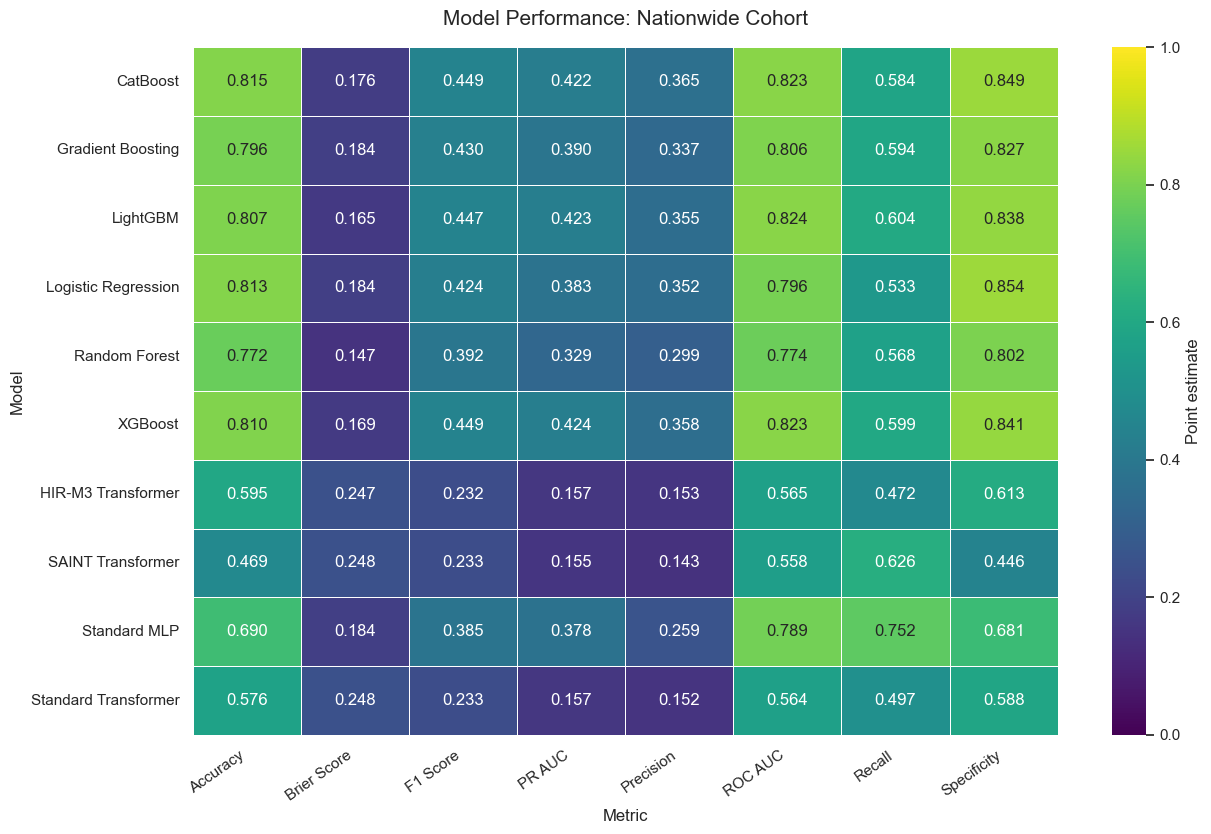

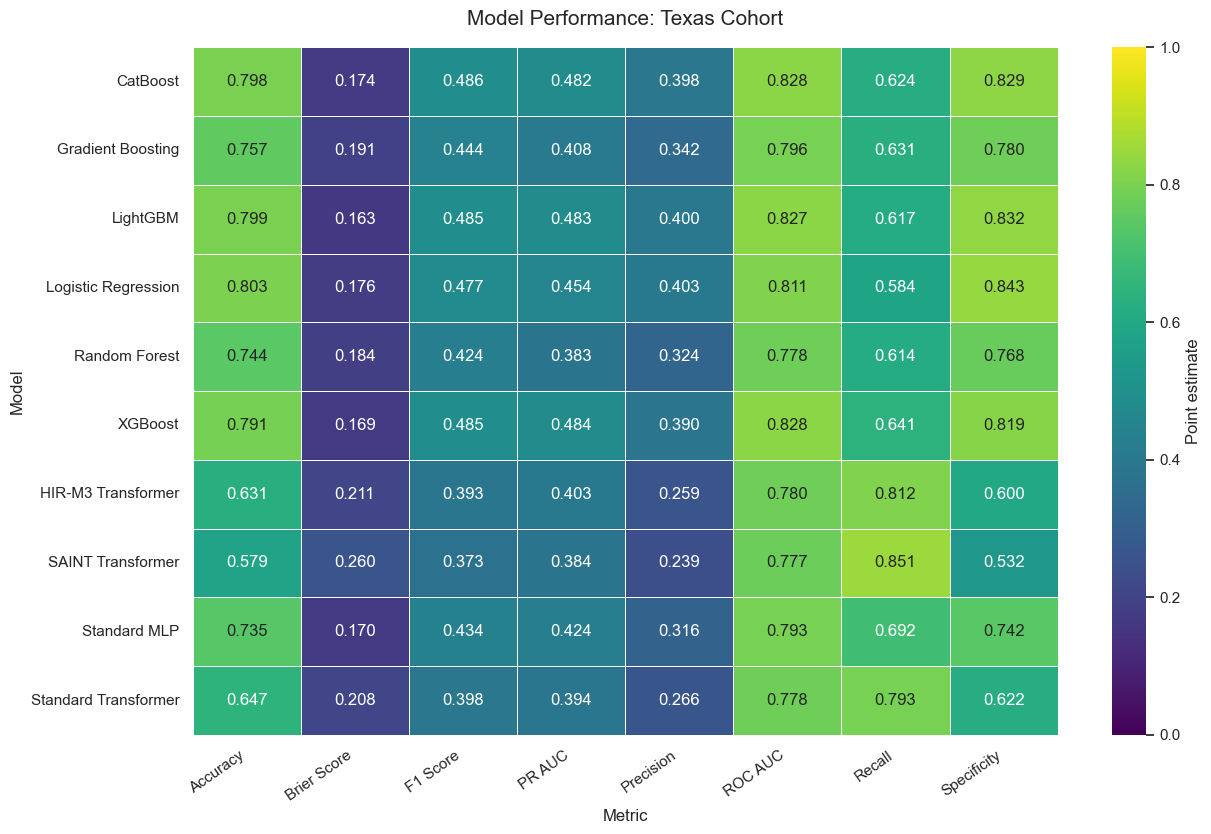

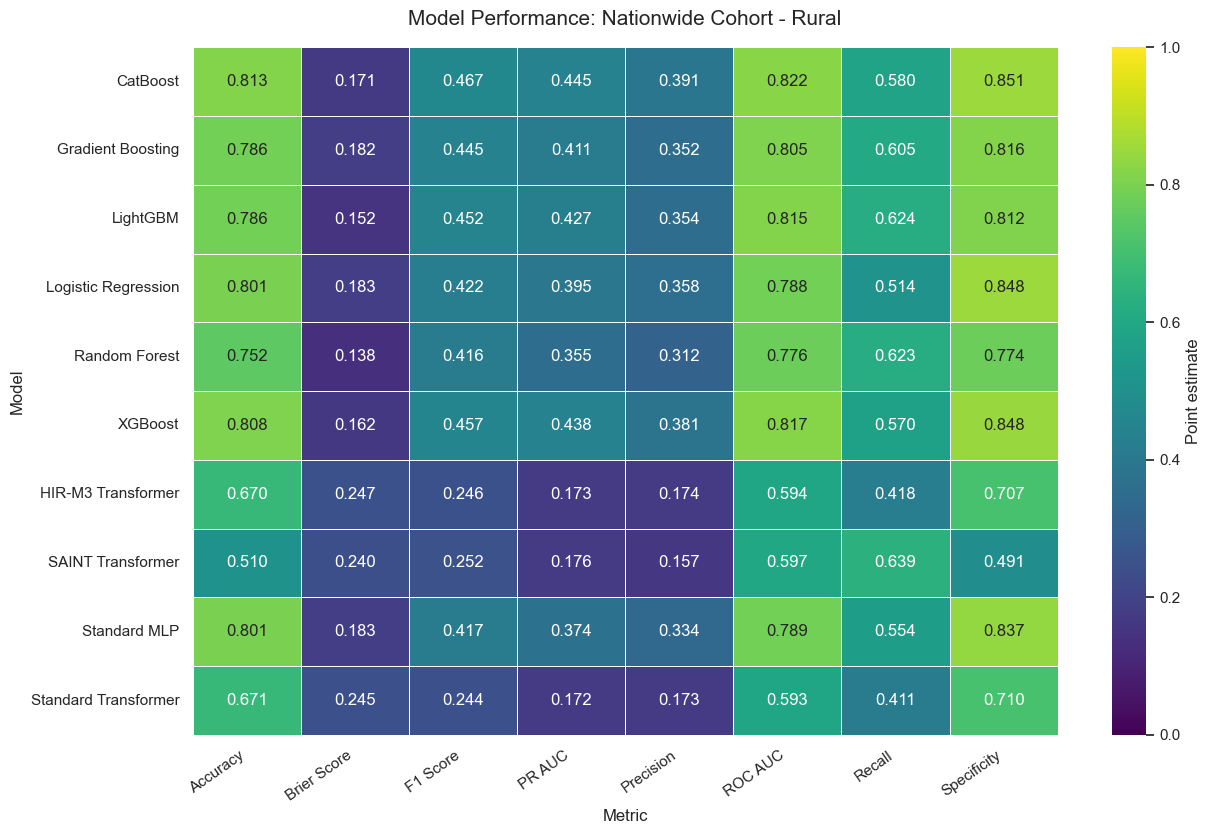

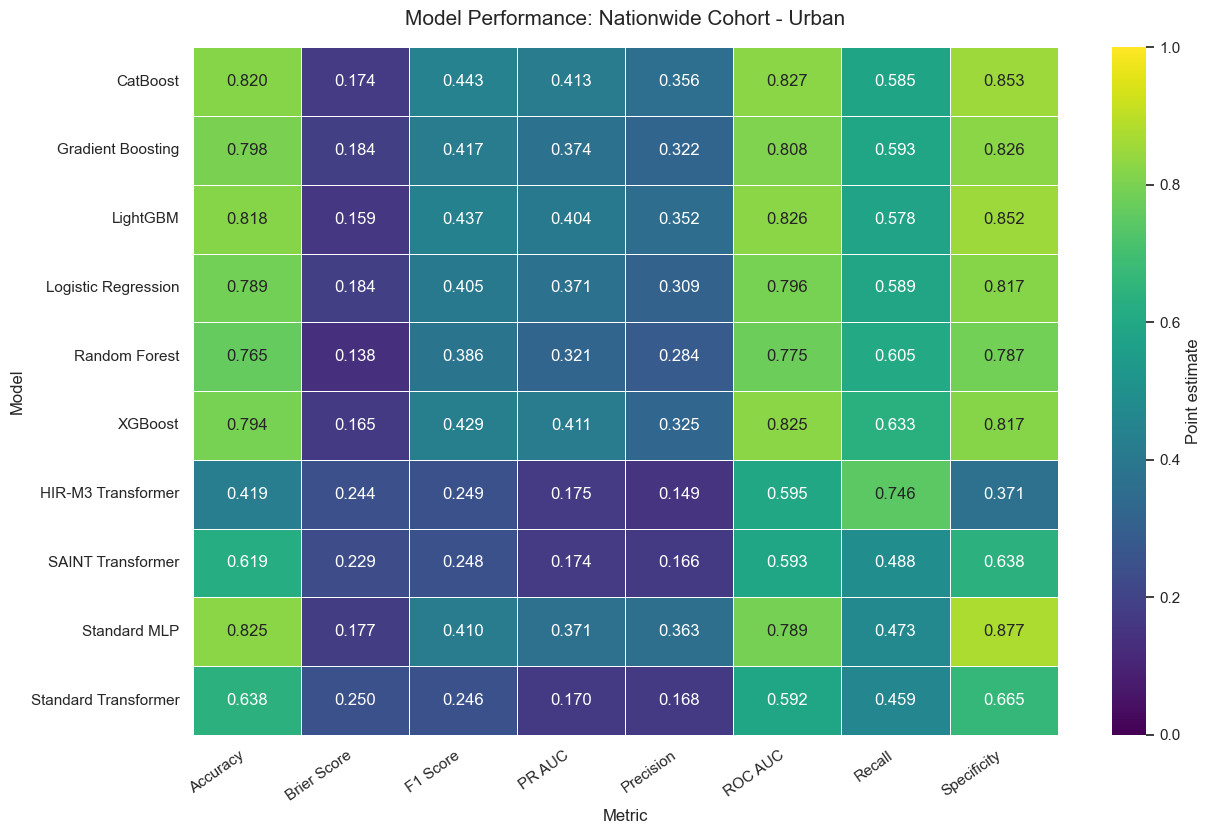

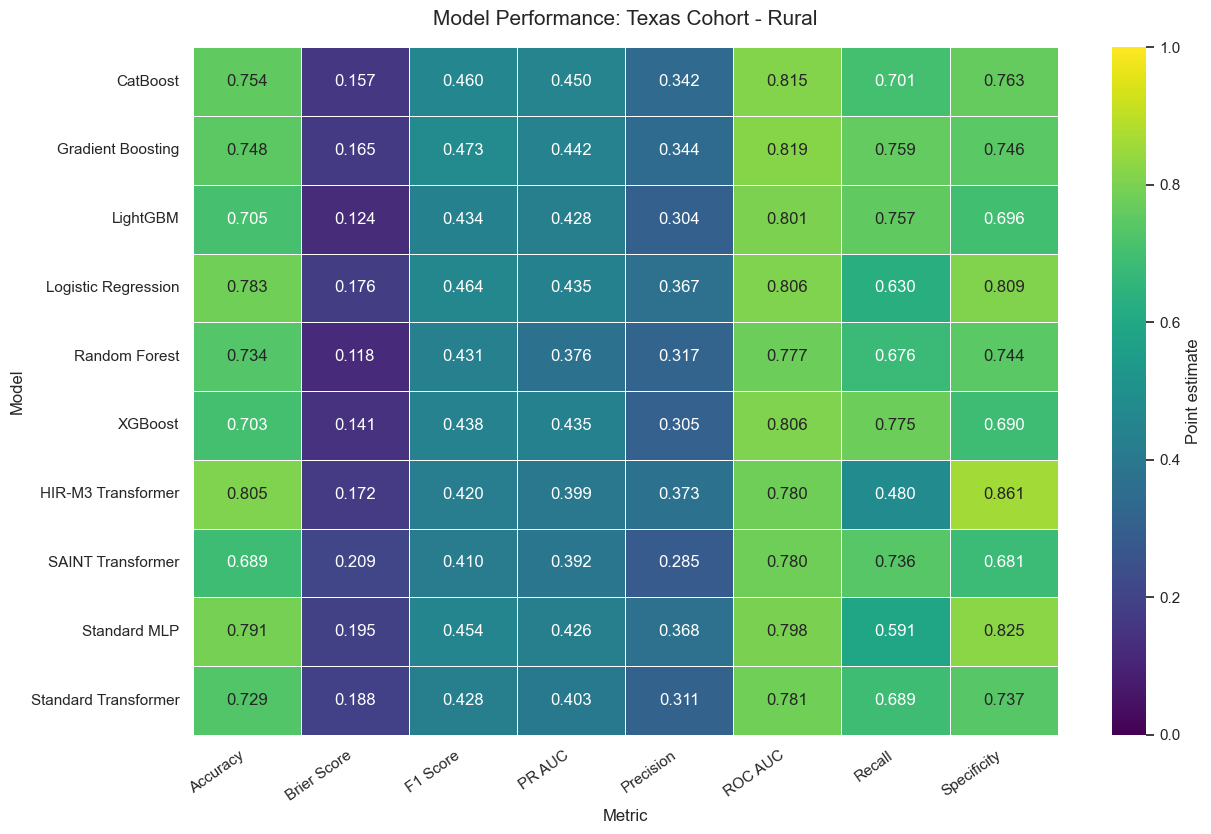

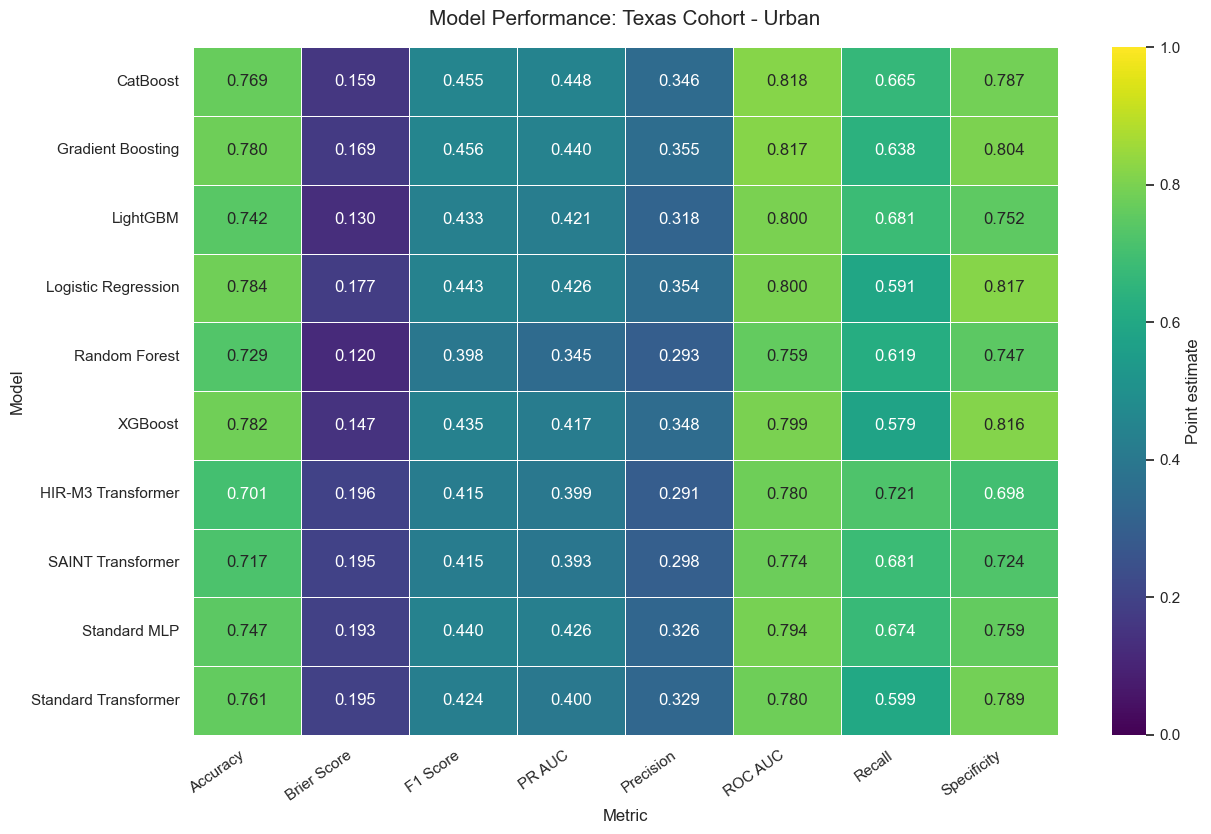

In [24]:
sns.set_theme(style="white", font_scale=1.0)

for cohort, cohort_df in modeling.groupby("Cohort", sort=False):

    heatmap_df = (
        cohort_df
        .set_index("Model")[[f"{metric}_value" for metric in metrics]]
        .rename(columns={
            f"{metric}_value": metric_labels[metric]
            for metric in metrics
        })
    )

    # Optional: makes Brier Score visually consistent with "higher is better"
    # Comment out this line if you want the original Brier Score values/colors.
    # heatmap_df["Brier Score"] = 1 - heatmap_df["Brier Score"]

    fig, ax = plt.subplots(
        figsize=(13, max(3.5, 0.75 * len(heatmap_df) + 1))
    )

    sns.heatmap(
        heatmap_df,
        ax=ax,
        annot=True,
        fmt=".3f",
        cmap="viridis",
        vmin=0,
        vmax=1,
        linewidths=0.7,
        linecolor="white",
        cbar_kws={"label": "Point estimate"},
    )

    ax.set_title(f"Model Performance: {cohort}", fontsize=15, pad=16)
    ax.set_xlabel("Metric", fontsize=12)
    ax.set_ylabel("Model", fontsize=12)

    plt.xticks(rotation=35, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    safe_name = (
        cohort.lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("/", "_")
    )

    fig.savefig(
        f"figs/{safe_name}_heatmap.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()
    plt.close(fig)

# Task 2

In [26]:
ratios = pd.read_csv('ensemble_ratios/ensemble_ratios_summary.csv')
ratios

,Cohort,Base Model,Target Model,Pair Name,Ensemble Ratio (Base:HIR),Weight Base Model,Weight HIR-M3,Threshold,ROC_AUC,ROC_AUC [95% CI],PR_AUC,PR_AUC [95% CI],F1_Score,F1 Score [95% CI],Brier_Score,Brier [95% CI],Accuracy,Precision,Recall,Sample Size
0,Texas Cohort,LightGBM,HIR-M3 Transformer,LightGBM + HIR-M3 Transformer,0:100,0.0,1.0,0.645489,0.813628,0.8138 (0.8047 - 0.8237),0.445896,0.4467 (0.4224 - 0.4727),0.474244,0.4741 (0.4582 - 0.4926),0.179587,0.1795 (0.1762 - 0.1833),0.798159,0.384251,0.619281,62449
1,Texas Cohort,XGBoost,HIR-M3 Transformer,XGBoost + HIR-M3 Transformer,30:70,0.3,0.7,0.622099,0.817927,0.8182 (0.8090 - 0.8274),0.454910,0.4558 (0.4281 - 0.4815),0.475289,0.4755 (0.4579 - 0.4937),0.169802,0.1697 (0.1664 - 0.1733),0.800240,0.387119,0.615468,62449
2,Texas Cohort,CatBoost,HIR-M3 Transformer,CatBoost + HIR-M3 Transformer,0:100,0.0,1.0,0.645489,0.813628,0.8138 (0.8047 - 0.8237),0.445896,0.4467 (0.4224 - 0.4727),0.474244,0.4741 (0.4582 - 0.4926),0.179587,0.1795 (0.1762 - 0.1833),0.798159,0.384251,0.619281,62449
3,Texas Cohort,Random Forest,HIR-M3 Transformer,Random Forest + HIR-M3 Transformer,0:100,0.0,1.0,0.645489,0.813628,0.8138 (0.8047 - 0.8237),0.445896,0.4467 (0.4224 - 0.4727),0.474244,0.4741 (0.4582 - 0.4926),0.179587,0.1795 (0.1762 - 0.1833),0.798159,0.384251,0.619281,62449
4,Texas Cohort,Gradient Boosting,HIR-M3 Transformer,Gradient Boosting + HIR-M3 Transformer,0:100,0.0,1.0,0.645489,0.813628,0.8138 (0.8047 - 0.8237),0.445896,0.4467 (0.4224 - 0.4727),0.474244,0.4741 (0.4582 - 0.4926),0.179587,0.1795 (0.1762 - 0.1833),0.798159,0.384251,0.619281,62449
5,Texas Cohort,Logistic Regression,HIR-M3 Transformer,Logistic Regression + HIR-M3 Transformer,0:100,0.0,1.0,0.645489,0.813628,0.8138 (0.8047 - 0.8237),0.445896,0.4467 (0.4224 - 0.4727),0.474244,0.4741 (0.4582 - 0.4926),0.179587,0.1795 (0.1762 - 0.1833),0.798159,0.384251,0.619281,62449
6,Nationwide Cohort,LightGBM,HIR-M3 Transformer,LightGBM + HIR-M3 Transformer,100:0,1.0,0.0,0.617139,0.823368,0.8235 (0.8189 - 0.8273),0.422317,0.4229 (0.4133 - 0.4314),0.446993,0.4474 (0.4389 - 0.4550),0.164793,0.1648 (0.1634 - 0.1662),0.807447,0.355073,0.603129,339308
7,Nationwide Cohort,XGBoost,HIR-M3 Transformer,XGBoost + HIR-M3 Transformer,90:10,0.9,0.1,0.645178,0.823131,0.8233 (0.8190 - 0.8275),0.424217,0.4249 (0.4143 - 0.4335),0.448286,0.4489 (0.4406 - 0.4558),0.173160,0.1732 (0.1716 - 0.1746),0.811898,0.360615,0.592280,339308
8,Nationwide Cohort,CatBoost,HIR-M3 Transformer,CatBoost + HIR-M3 Transformer,100:0,1.0,0.0,0.648668,0.822477,0.8227 (0.8184 - 0.8270),0.421023,0.4218 (0.4124 - 0.4309),0.448825,0.4492 (0.4415 - 0.4572),0.176405,0.1764 (0.1749 - 0.1778),0.815022,0.364577,0.583714,339308
9,Nationwide Cohort,Random Forest,HIR-M3 Transformer,Random Forest + HIR-M3 Transformer,70:30,0.7,0.3,0.485189,0.802968,0.8031 (0.7987 - 0.8078),0.363576,0.3645 (0.3549 - 0.3739),0.413559,0.4140 (0.4078 - 0.4202),0.159950,0.1599 (0.1591 - 0.1610),0.739972,0.291647,0.710598,339308


In [27]:
ratios.columns

Index(['Cohort', 'Base Model', 'Target Model', 'Pair Name',
       'Ensemble Ratio (Base:HIR)', 'Weight Base Model', 'Weight HIR-M3',
       'Threshold', 'ROC_AUC', 'ROC_AUC [95% CI]', 'PR_AUC', 'PR_AUC [95% CI]',
       'F1_Score', 'F1 Score [95% CI]', 'Brier_Score', 'Brier [95% CI]',
       'Accuracy', 'Precision', 'Recall', 'Sample Size'],
      dtype='str')

In [29]:
results_wide_ratios = ratios[['Cohort', 'Base Model', 'Target Model','Pair Name','Ensemble Ratio (Base:HIR)',
                              'ROC_AUC [95% CI]', 'PR_AUC [95% CI]','F1 Score [95% CI]', 'Brier [95% CI]']]


results_wide_ratios = results_wide_ratios.reset_index()
results_wide_ratios

,index,Cohort,Base Model,Target Model,Pair Name,Ensemble Ratio (Base:HIR),ROC_AUC [95% CI],PR_AUC [95% CI],F1 Score [95% CI],Brier [95% CI]
0,0,Texas Cohort,LightGBM,HIR-M3 Transformer,LightGBM + HIR-M3 Transformer,0:100,0.8138 (0.8047 - 0.8237),0.4467 (0.4224 - 0.4727),0.4741 (0.4582 - 0.4926),0.1795 (0.1762 - 0.1833)
1,1,Texas Cohort,XGBoost,HIR-M3 Transformer,XGBoost + HIR-M3 Transformer,30:70,0.8182 (0.8090 - 0.8274),0.4558 (0.4281 - 0.4815),0.4755 (0.4579 - 0.4937),0.1697 (0.1664 - 0.1733)
2,2,Texas Cohort,CatBoost,HIR-M3 Transformer,CatBoost + HIR-M3 Transformer,0:100,0.8138 (0.8047 - 0.8237),0.4467 (0.4224 - 0.4727),0.4741 (0.4582 - 0.4926),0.1795 (0.1762 - 0.1833)
3,3,Texas Cohort,Random Forest,HIR-M3 Transformer,Random Forest + HIR-M3 Transformer,0:100,0.8138 (0.8047 - 0.8237),0.4467 (0.4224 - 0.4727),0.4741 (0.4582 - 0.4926),0.1795 (0.1762 - 0.1833)
4,4,Texas Cohort,Gradient Boosting,HIR-M3 Transformer,Gradient Boosting + HIR-M3 Transformer,0:100,0.8138 (0.8047 - 0.8237),0.4467 (0.4224 - 0.4727),0.4741 (0.4582 - 0.4926),0.1795 (0.1762 - 0.1833)
5,5,Texas Cohort,Logistic Regression,HIR-M3 Transformer,Logistic Regression + HIR-M3 Transformer,0:100,0.8138 (0.8047 - 0.8237),0.4467 (0.4224 - 0.4727),0.4741 (0.4582 - 0.4926),0.1795 (0.1762 - 0.1833)
6,6,Nationwide Cohort,LightGBM,HIR-M3 Transformer,LightGBM + HIR-M3 Transformer,100:0,0.8235 (0.8189 - 0.8273),0.4229 (0.4133 - 0.4314),0.4474 (0.4389 - 0.4550),0.1648 (0.1634 - 0.1662)
7,7,Nationwide Cohort,XGBoost,HIR-M3 Transformer,XGBoost + HIR-M3 Transformer,90:10,0.8233 (0.8190 - 0.8275),0.4249 (0.4143 - 0.4335),0.4489 (0.4406 - 0.4558),0.1732 (0.1716 - 0.1746)
8,8,Nationwide Cohort,CatBoost,HIR-M3 Transformer,CatBoost + HIR-M3 Transformer,100:0,0.8227 (0.8184 - 0.8270),0.4218 (0.4124 - 0.4309),0.4492 (0.4415 - 0.4572),0.1764 (0.1749 - 0.1778)
9,9,Nationwide Cohort,Random Forest,HIR-M3 Transformer,Random Forest + HIR-M3 Transformer,70:30,0.8031 (0.7987 - 0.8078),0.3645 (0.3549 - 0.3739),0.4140 (0.4078 - 0.4202),0.1599 (0.1591 - 0.1610)


In [31]:
results_wide_ratios.to_csv('ensemble_ratios/ratios_summary.csv')

In [30]:
modeling

,Cohort,Cohort Size,Num Features,Model,Accuracy_Formatted,Brier_Score_Formatted,F1_Score_Formatted,PR_AUC_Formatted,Precision_Formatted,ROC_AUC_Formatted,Recall_Sensitivity_Formatted,Specificity_Formatted,Accuracy_Formatted_value,Brier_Score_Formatted_value,F1_Score_Formatted_value,PR_AUC_Formatted_value,Precision_Formatted_value,ROC_AUC_Formatted_value,Recall_Sensitivity_Formatted_value,Specificity_Formatted_value
0,Nationwide Cohort,339308,2077,CatBoost,0.8150 (0.8117 - 0.8181),0.1764 (0.1749 - 0.1778),0.4492 (0.4415 - 0.4572),0.4218 (0.4124 - 0.4309),0.3650 (0.3567 - 0.3726),0.8227 (0.8184 - 0.8270),0.5839 (0.5747 - 0.5935),0.8493 (0.8464 - 0.8521),0.8150,0.1764,0.4492,0.4218,0.3650,0.8227,0.5839,0.8493
1,Nationwide Cohort,339308,2077,Gradient Boosting,0.7965 (0.7937 - 0.7995),0.1845 (0.1833 - 0.1857),0.4297 (0.4225 - 0.4365),0.3900 (0.3810 - 0.3994),0.3368 (0.3302 - 0.3428),0.8062 (0.8013 - 0.8106),0.5935 (0.5840 - 0.6036),0.8266 (0.8237 - 0.8299),0.7965,0.1845,0.4297,0.3900,0.3368,0.8062,0.5935,0.8266
2,Nationwide Cohort,339308,2077,LightGBM,0.8074 (0.8038 - 0.8104),0.1648 (0.1634 - 0.1662),0.4474 (0.4389 - 0.4550),0.4229 (0.4133 - 0.4314),0.3554 (0.3477 - 0.3623),0.8235 (0.8189 - 0.8273),0.6036 (0.5930 - 0.6139),0.8376 (0.8344 - 0.8404),0.8074,0.1648,0.4474,0.4229,0.3554,0.8235,0.6036,0.8376
3,Nationwide Cohort,339308,2077,Logistic Regression,0.8127 (0.8101 - 0.8153),0.1839 (0.1824 - 0.1852),0.4238 (0.4169 - 0.4321),0.3825 (0.3731 - 0.3922),0.3517 (0.3443 - 0.3596),0.7959 (0.7911 - 0.8002),0.5332 (0.5234 - 0.5448),0.8542 (0.8514 - 0.8570),0.8127,0.1839,0.4238,0.3825,0.3517,0.7959,0.5332,0.8542
4,Nationwide Cohort,339308,2077,Random Forest,0.7720 (0.7686 - 0.7750),0.1474 (0.1466 - 0.1483),0.3918 (0.3845 - 0.3984),0.3290 (0.3195 - 0.3378),0.2989 (0.2926 - 0.3047),0.7739 (0.7690 - 0.7785),0.5684 (0.5583 - 0.5779),0.8022 (0.7987 - 0.8054),0.7720,0.1474,0.3918,0.3290,0.2989,0.7739,0.5684,0.8022
5,Nationwide Cohort,339308,2077,XGBoost,0.8097 (0.8063 - 0.8127),0.1688 (0.1674 - 0.1702),0.4486 (0.4409 - 0.4559),0.4244 (0.4141 - 0.4331),0.3584 (0.3509 - 0.3649),0.8228 (0.8186 - 0.8270),0.5993 (0.5893 - 0.6096),0.8409 (0.8375 - 0.8442),0.8097,0.1688,0.4486,0.4244,0.3584,0.8228,0.5993,0.8409
6,Texas Cohort,222953,4108,CatBoost,0.7976 (0.7934 - 0.8015),0.1737 (0.1720 - 0.1760),0.4858 (0.4766 - 0.4938),0.4821 (0.4696 - 0.4936),0.3979 (0.3891 - 0.4070),0.8276 (0.8228 - 0.8321),0.6235 (0.6107 - 0.6353),0.8291 (0.8249 - 0.8331),0.7976,0.1737,0.4858,0.4821,0.3979,0.8276,0.6235,0.8291
7,Texas Cohort,222953,4108,Gradient Boosting,0.7571 (0.7532 - 0.7624),0.1906 (0.1893 - 0.1918),0.4436 (0.4350 - 0.4503),0.4080 (0.3966 - 0.4190),0.3420 (0.3339 - 0.3494),0.7957 (0.7908 - 0.8005),0.6311 (0.6197 - 0.6426),0.7800 (0.7759 - 0.7846),0.7571,0.1906,0.4436,0.4080,0.3420,0.7957,0.6311,0.7800
8,Texas Cohort,222953,4108,LightGBM,0.7990 (0.7948 - 0.8035),0.1633 (0.1615 - 0.1654),0.4848 (0.4762 - 0.4924),0.4829 (0.4715 - 0.4945),0.3995 (0.3913 - 0.4074),0.8272 (0.8226 - 0.8320),0.6166 (0.6044 - 0.6279),0.8321 (0.8281 - 0.8360),0.7990,0.1633,0.4848,0.4829,0.3995,0.8272,0.6166,0.8321
9,Texas Cohort,222953,4108,Logistic Regression,0.8033 (0.7992 - 0.8072),0.1759 (0.1740 - 0.1780),0.4767 (0.4671 - 0.4861),0.4536 (0.4415 - 0.4648),0.4027 (0.3934 - 0.4130),0.8110 (0.8060 - 0.8157),0.5840 (0.5731 - 0.5965),0.8431 (0.8388 - 0.8466),0.8033,0.1759,0.4767,0.4536,0.4027,0.8110,0.5840,0.8431


# Task 2 Results: HIR-M3 Ensemble Ratio Evaluation

## Overview

Task 2 evaluated weighted probability ensembles combining HIR-M3 Transformer with conventional machine-learning models. Ensemble ratios are expressed as **Base Model:HIR-M3**. Performance was assessed using ROC AUC, PR AUC, F1 score, and Brier score with 95% confidence intervals.

Overall, the results indicate that the optimal HIR-M3 contribution differs by cohort. In the Nationwide cohort, the best configurations were primarily conventional-model dominant, with zero or minimal HIR-M3 weight. In Texas, the strongest ensemble was a HIR-M3-dominant XGBoost combination, although most other pairings selected HIR-M3 alone.

## Nationwide Cohort

In the Nationwide cohort, LightGBM alone had the highest ROC AUC and best Brier score among the selected configurations. CatBoost alone had the highest F1 score. XGBoost with a small HIR-M3 contribution had the highest PR AUC.

| Ensemble | Ratio (Base:HIR-M3) | ROC AUC [95% CI] | PR AUC [95% CI] | F1 Score [95% CI] | Brier [95% CI] |
|---|---:|---|---|---|---|
| LightGBM + HIR-M3 | 100:0 | 0.8235 (0.8189–0.8273) | 0.4229 (0.4133–0.4314) | 0.4474 (0.4389–0.4550) | 0.1648 (0.1634–0.1662) |
| XGBoost + HIR-M3 | 90:10 | 0.8233 (0.8190–0.8275) | 0.4249 (0.4143–0.4335) | 0.4489 (0.4406–0.4558) | 0.1732 (0.1716–0.1746) |
| CatBoost + HIR-M3 | 100:0 | 0.8227 (0.8184–0.8270) | 0.4218 (0.4124–0.4309) | 0.4492 (0.4415–0.4572) | 0.1764 (0.1749–0.1778) |
| Random Forest + HIR-M3 | 70:30 | 0.8031 (0.7987–0.8078) | 0.3645 (0.3549–0.3739) | 0.4140 (0.4078–0.4202) | 0.1599 (0.1591–0.1610) |
| Gradient Boosting + HIR-M3 | 90:10 | 0.8094 (0.8046–0.8137) | 0.3946 (0.3857–0.4037) | 0.4328 (0.4259–0.4400) | 0.1868 (0.1856–0.1880) |
| Logistic Regression + HIR-M3 | 100:0 | 0.7959 (0.7911–0.8002) | 0.3825 (0.3731–0.3922) | 0.4238 (0.4164–0.4319) | 0.1839 (0.1824–0.1852) |

The Nationwide results do not support a large HIR-M3 contribution. LightGBM, CatBoost, and Logistic Regression selected a 100:0 ratio, indicating that the strongest configuration for those pairings was the base model alone. XGBoost and Gradient Boosting selected 90:10 ratios, suggesting that HIR-M3 may offer only a small complementary contribution for these models.

The 90:10 XGBoost + HIR-M3 ensemble achieved the highest PR AUC (0.4249), while CatBoost alone achieved the highest F1 score (0.4492). LightGBM alone achieved the highest ROC AUC (0.8235) and the lowest Brier score among the high-discrimination models (0.1648). The confidence intervals for LightGBM, XGBoost, and CatBoost overlap substantially, so small numerical differences should not be interpreted as definitive superiority.

## Texas Cohort

In Texas, the strongest selected ensemble was **30% XGBoost + 70% HIR-M3**. This configuration had the highest ROC AUC, PR AUC, F1 score, and best Brier score among the evaluated Texas ensemble pairings.

| Ensemble | Ratio (Base:HIR-M3) | ROC AUC [95% CI] | PR AUC [95% CI] | F1 Score [95% CI] | Brier [95% CI] |
|---|---:|---|---|---|---|
| LightGBM + HIR-M3 | 0:100 | 0.8138 (0.8047–0.8237) | 0.4467 (0.4224–0.4727) | 0.4741 (0.4582–0.4926) | 0.1795 (0.1762–0.1833) |
| XGBoost + HIR-M3 | 30:70 | 0.8182 (0.8090–0.8274) | 0.4558 (0.4281–0.4815) | 0.4755 (0.4579–0.4937) | 0.1697 (0.1664–0.1733) |
| CatBoost + HIR-M3 | 0:100 | 0.8138 (0.8047–0.8237) | 0.4467 (0.4224–0.4727) | 0.4741 (0.4582–0.4926) | 0.1795 (0.1762–0.1833) |
| Random Forest + HIR-M3 | 0:100 | 0.8138 (0.8047–0.8237) | 0.4467 (0.4224–0.4727) | 0.4741 (0.4582–0.4926) | 0.1795 (0.1762–0.1833) |
| Gradient Boosting + HIR-M3 | 0:100 | 0.8138 (0.8047–0.8237) | 0.4467 (0.4224–0.4727) | 0.4741 (0.4582–0.4926) | 0.1795 (0.1762–0.1833) |
| Logistic Regression + HIR-M3 | 0:100 | 0.8138 (0.8047–0.8237) | 0.4467 (0.4224–0.4727) | 0.4741 (0.4582–0.4926) | 0.1795 (0.1762–0.1833) |

The 30:70 XGBoost + HIR-M3 ensemble achieved ROC AUC of 0.8182, PR AUC of 0.4558, F1 score of 0.4755, and Brier score of 0.1697. Relative to HIR-M3 alone, adding 30% XGBoost improved all four reported metrics, including a lower Brier score (0.1697 versus 0.1795).

For the other Texas pairings, the selected 0:100 ratio means that the best tested configuration was HIR-M3 alone. This does not establish that HIR-M3 is superior to the standalone conventional models from Task 1; rather, it indicates that no tested blend with those specific base models outperformed HIR-M3 under the ratio-selection procedure and metrics summarized here.

## Interpretation

The ensemble analysis supports different strategies by cohort:

- **Nationwide:** Favor conventional models. LightGBM alone is the leading option for ROC AUC and Brier score, CatBoost alone has the highest F1 score, and XGBoost + HIR-M3 at 90:10 is a secondary candidate because it achieved the highest PR AUC.
- **Texas:** Retain the 30:70 XGBoost + HIR-M3 ensemble as the leading ensemble candidate because it outperformed HIR-M3 alone across ROC AUC, PR AUC, F1 score, and Brier score.
- **Generalizability:** A single universal HIR-M3 ensemble ratio is not supported. Nationwide results favor zero to minimal HIR-M3 weight, whereas Texas favors a HIR-M3-dominant XGBoost blend.

## Recommended Next Steps

Before selecting a final ensemble for use, compare the leading candidates at clinically meaningful thresholds using recall, specificity, precision, confusion matrices, calibration curves, and subgroup-specific error rates. These analyses are particularly important because HIR-M3 was carried forward due to its high-recall profile, and the current ratio summary does not include the corresponding false-positive and false-negative trade-offs.

### Task 3 Final Models

#### Nationwide Cohort

1. LightGBM baseline
2. XGBoost baseline
3. HIR-M3 Transformer
4. XGBoost + HIR-M3 Transformer ensemble (90:10)
5. LightGBM with ACT-parity threshold
6. XGBoost with ACT-parity threshold
7. HIR-M3 Transformer with ACT-parity threshold
8. XGBoost + HIR-M3 Transformer ensemble (90:10) with ACT-parity threshold

#### Texas Cohort

1. CatBoost baseline
2. XGBoost baseline
3. HIR-M3 Transformer
4. XGBoost + HIR-M3 Transformer ensemble (30:70)
5. CatBoost with ACT-parity threshold
6. XGBoost with ACT-parity threshold
7. HIR-M3 Transformer with ACT-parity threshold
8. XGBoost + HIR-M3 Transformer ensemble (30:70) with ACT-parity threshold